# 📊 BubbleSeg — Experiment Analysis Notebook
This notebook loads evaluation results from the synthetic or real datasets,  
visualizes experiment metrics, and generates thesis-ready tables and figures.

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from plotting_module import (
    load_experiment,
    run_all_plots_for_experiment,
    generate_experiment_comparison,
)

In [2]:
# Example: use your own experiment output folder
exp_dir = "results/maskrcnn_resnet50_fpn_synth_20251128_2154"

In [3]:
exp = load_experiment(exp_dir)

df = exp["df"]
summary = exp["json"]

df.head(), summary

(   ImageIdx  Precision    Recall        F1      Dice       IoU  NumBubbles  \
 0         0   0.937672  0.990238  0.963238  0.963238  0.929083           4   
 1         1   0.991391  0.955381  0.973053  0.973053  0.947521          11   
 2         2   0.998797  0.941047  0.969063  0.969063  0.939982           4   
 3         3   0.901282  0.995608  0.946100  0.946100  0.897713          15   
 4         4   0.931043  0.990335  0.959774  0.959774  0.922659           2   
 
       MeanArea  MedianArea  
 0  2731.500000      2540.5  
 1  1959.000000      1798.0  
 2  6446.000000      6551.5  
 3  1494.533333      1438.0  
 4  7758.500000      7758.5  ,
 {'semantic_metrics': {'precision': 0.9693911028149345,
   'recall': 0.9729822758706299,
   'f1': 0.9707433909638591,
   'dice': 0.9707433909414953,
   'iou': 0.9432868132843159},
  'instance_metrics': {'avg_bubbles': 10.586666666666666,
   'mean_area': 4616.681302484184,
   'median_area': 4444.193333333334},
  'timing': {'avg_infer_time': 0

In [4]:
run_all_plots_for_experiment(exp_dir)

Generating plots for maskrcnn_resnet50_fpn_synth_20251128_2154 ...
Plots saved to results/maskrcnn_resnet50_fpn_synth_20251128_2154/plots
Finished plotting for: results/maskrcnn_resnet50_fpn_synth_20251128_2154


In [5]:
print("Semantic Metrics:")
for k, v in summary["semantic_metrics"].items():
    print(f" - {k}: {v:.4f}")

print("\nInstance Metrics:")
for k, v in summary["instance_metrics"].items():
    print(f" - {k}: {v:.4f}")

print("\nTiming Metrics:")
for k, v in summary["timing"].items():
    print(f" - {k}: {v:.4f}")

Semantic Metrics:
 - precision: 0.9694
 - recall: 0.9730
 - f1: 0.9707
 - dice: 0.9707
 - iou: 0.9433

Instance Metrics:
 - avg_bubbles: 10.5867
 - mean_area: 4616.6813
 - median_area: 4444.1933

Timing Metrics:
 - avg_infer_time: 0.1477
 - fps: 6.7700


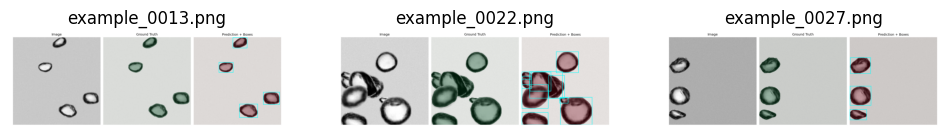

In [6]:
import os
import matplotlib.pyplot as plt
from PIL import Image

examples_dir = summary["examples_dir"]
examples = sorted(os.listdir(examples_dir))

plt.figure(figsize=(12, 6))
for i, fname in enumerate(examples[:3]):
    img = Image.open(os.path.join(examples_dir, fname))
    plt.subplot(1, 3, i+1)
    plt.imshow(img)
    plt.title(fname)
    plt.axis("off")

plt.show()

In [7]:
import pandas as pd

table = pd.DataFrame({
    "Metric": summary["semantic_metrics"].keys(),
    "Value": summary["semantic_metrics"].values()
})

print(table.to_latex(index=False))

\begin{tabular}{lr}
\toprule
Metric & Value \\
\midrule
precision & 0.969391 \\
recall & 0.972982 \\
f1 & 0.970743 \\
dice & 0.970743 \\
iou & 0.943287 \\
\bottomrule
\end{tabular}



In [8]:
experiments = [
    "results/maskrcnn_resnet50_fpn_synth_20251128_2154",
    "results/maskrcnn_resnet50_fpn_synth_20251128_2227",
    "results/maskrcnn_resnet50_fpn_synth_20251128_2228",
]

generate_experiment_comparison(experiments, out_dir="comparison_plots")

Comparing experiments:
 - results/maskrcnn_resnet50_fpn_synth_20251128_2154
 - results/maskrcnn_resnet50_fpn_synth_20251128_2227
 - results/maskrcnn_resnet50_fpn_synth_20251128_2228


In [9]:
print(f"""
The model achieved a mean Dice score of {summary['semantic_metrics']['dice']:.4f}
and a mean IoU of {summary['semantic_metrics']['iou']:.4f}, demonstrating strong ability 
to segment bubble regions accurately.

The average number of detected bubbles per image was 
{summary['instance_metrics']['avg_bubbles']:.2f}, with a mean bubble area of 
{summary['instance_metrics']['mean_area']:.1f} pixels.

The inference speed was {summary['timing']['fps']:.1f} FPS, which is suitable for 
real-time or near-real-time applications depending on deployment requirements.
""")


The model achieved a mean Dice score of 0.9707
and a mean IoU of 0.9433, demonstrating strong ability 
to segment bubble regions accurately.

The average number of detected bubbles per image was 
10.59, with a mean bubble area of 
4616.7 pixels.

The inference speed was 6.8 FPS, which is suitable for 
real-time or near-real-time applications depending on deployment requirements.

